# Benchmark Klasik H₂ / STO-3G
### Rigid Scan — HF vs B3LYP vs CASSCF vs FCI
- Range 1: R = 0.50–3.00 Å (16 titik)
- Range 2: R = 3.00–5.80 Å (16 titik)
- Gabungan: R = 0.50–5.80 Å (31 titik, titik R=3.00 tidak duplikat)

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# ══════════════════════════════════════════════
# DATA RANGE 1 — R = 0.50–3.00 Å, 16 titik
# ══════════════════════════════════════════════
R1 = list(np.linspace(0.50, 3.00, 16))

E_HF_1 = [
     0.164175000091,
    -0.876006556526,
    -1.090833133608,
    -1.115380658972,
    -1.080498447795,
    -1.026195117184,
    -0.966730795630,
    -0.908881335616,
    -0.856105888411,
    -0.809877094615,
    -0.770506805582,
    -0.737634990089,
    -0.710553420669,
    -0.688442403534,
    -0.670511003889,
    -0.656048250140
]

E_DFT_1 = [
     0.127222448196,
    -0.911956142601,
    -1.128483874232,
    -1.157974933992,
    -1.130736971224,
    -1.086417216037,
    -1.038745613941,
    -0.993618513297,
    -0.953597761372,
    -0.919500012515,
    -0.891260833308,
    -0.868364366999,
    -0.850081847224,
    -0.835660283260,
    -0.824414070586,
    -0.815742055632
]

# Untuk H2/STO-3G dengan CAS(2,2): CASSCF = CASCI = FCI (full valence space)
E_FCI_1 = [
     0.157482122817,
    -0.885521699518,
    -1.105128175610,
    -1.136795618671,
    -1.111988626737,
    -1.071684428714,
    -1.031072673146,
    -0.997087627975,
    -0.972151067249,
    -0.955680577548,
    -0.945658184381,
    -0.939905685719,
    -0.936726741861,
    -0.935011992918,
    -0.934103908440,
    -0.933631844530
]

E_CASSCF_1 = E_FCI_1  # identik untuk H2/STO-3G CAS(2,2)

# ══════════════════════════════════════════════
# DATA RANGE 2 — R = 3.00–5.80 Å, 16 titik
# ══════════════════════════════════════════════
R2 = list(np.linspace(3.00, 5.80, 16))

E_HF_2 = [
    -0.656048250140,
    -0.644426377329,
    -0.635094132525,
    -0.627575001471,
    -0.621468570678,
    -0.616449581667,
    -0.612262244402,
    -0.608710686226,
    -0.605647760046,
    -0.602964198353,
    -0.600579266892,
    -0.598433298911,
    -0.596482010825,
    -0.594692293234,
    -0.593039136913,
    -0.591503400844
]

E_DFT_2 = [
    -0.815742055632,
    -0.809129872044,
    -0.804131964484,
    -0.800394174771,
    -0.797616400159,
    -0.795528849985,
    -0.793933999861,
    -0.792710319645,
    -0.791763726309,
    -0.791019942535,
    -0.790419577803,
    -0.789909984086,
    -0.789459014537,
    -0.789054627736,
    -0.788690964976,
    -0.788360588069
]

E_FCI_2 = [
    -0.933631844530,
    -0.933391588584,
    -0.933272149318,
    -0.933214189979,
    -0.933186714456,
    -0.933173973014,
    -0.933168186917,
    -0.933165613944,
    -0.933164495058,
    -0.933164020435,
    -0.933163824687,
    -0.933163746475,
    -0.933163716306,
    -0.933163705107,
    -0.933163701116,
    -0.933163699754
]

E_CASSCF_2 = E_FCI_2  # identik untuk H2/STO-3G CAS(2,2)

# ══════════════════════════════════════════════
# DATA GABUNGAN (skip titik R=3.00 dari Range 2
# karena sudah ada di ujung Range 1)
# ══════════════════════════════════════════════
R_gab      = R1 + R2[1:]
E_HF_gab   = E_HF_1   + E_HF_2[1:]
E_DFT_gab  = E_DFT_1  + E_DFT_2[1:]
E_FCI_gab  = E_FCI_1  + E_FCI_2[1:]
E_CASSCF_gab = E_CASSCF_1 + E_CASSCF_2[1:]

print(f'Jumlah titik Range 1   : {len(R1)}')
print(f'Jumlah titik Range 2   : {len(R2)}')
print(f'Jumlah titik Gabungan  : {len(R_gab)}')

Jumlah titik Range 1   : 16
Jumlah titik Range 2   : 16
Jumlah titik Gabungan  : 31


## Plot 1 — Range 1: R = 0.50–3.00 Å

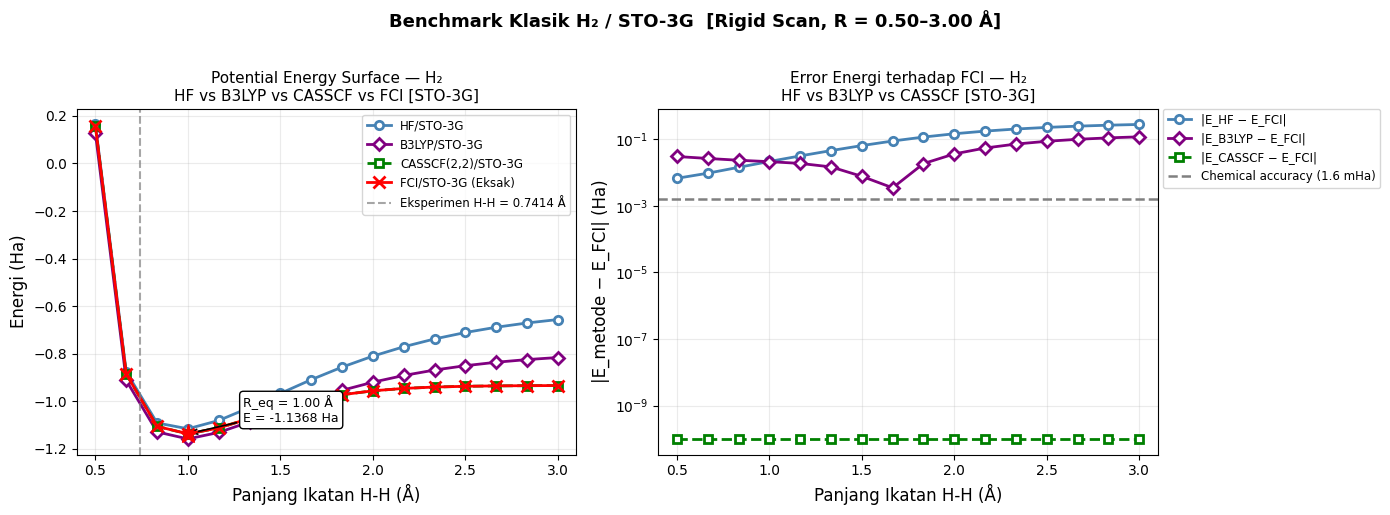

Tersimpan: Benchmark_H2_Rigid_Scan,_R_=_0.50–3.00_Å.png


In [2]:
def plot_h2(R, E_HF, E_DFT, E_CASSCF, E_FCI, title_suffix, xlim):
    """Helper fungsi plot PES + Error H2 supaya tidak perlu nulis ulang 3x."""
    e_ref        = np.array(E_FCI)
    error_hf     = np.abs(np.array(E_HF)     - e_ref)
    error_dft    = np.abs(np.array(E_DFT)    - e_ref)
    error_casscf = np.abs(np.array(E_CASSCF) - e_ref)
    CA = 0.0016

    idx_fci = list(E_FCI).index(min(E_FCI))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
    fig.patch.set_facecolor('white')

    # ── Panel Kiri: PES ──
    ax1.plot(R, E_HF,     'o-',  color='steelblue', linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='HF/STO-3G')
    ax1.plot(R, E_DFT,    'D-',  color='purple',    linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='B3LYP/STO-3G')
    ax1.plot(R, E_CASSCF, 's--', color='green',     linewidth=2,
             markersize=6, markerfacecolor='white', markeredgewidth=2,
             label='CASSCF(2,2)/STO-3G')
    ax1.plot(R, E_FCI,    'x-',  color='red',       linewidth=2,
             markersize=8, markeredgewidth=2,
             label='FCI/STO-3G (Eksak)')

    ax1.plot(R[idx_fci], E_FCI[idx_fci], 'r*', markersize=14, zorder=5)
    ax1.annotate(f'R_eq = {R[idx_fci]:.2f} Å\nE = {E_FCI[idx_fci]:.4f} Ha',
                 xy=(R[idx_fci], E_FCI[idx_fci]),
                 xytext=(R[idx_fci]+0.3, E_FCI[idx_fci]+0.05),
                 arrowprops=dict(arrowstyle='->', color='black', lw=1.2),
                 fontsize=9,
                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='black'))

    ax1.axvline(x=0.7414, color='gray', linestyle='--', linewidth=1.5, alpha=0.7,
                label='Eksperimen H-H = 0.7414 Å')
    ax1.set_xlim(xlim)
    ax1.set_xlabel('Panjang Ikatan H-H (Å)', fontsize=12)
    ax1.set_ylabel('Energi (Ha)', fontsize=12)
    ax1.set_title(f'Potential Energy Surface — H₂\nHF vs B3LYP vs CASSCF vs FCI [STO-3G]',
                  fontsize=11)
    ax1.legend(fontsize=8.5, loc='upper right')
    ax1.grid(True, alpha=0.25)

    # ── Panel Kanan: Error vs FCI ──
    ax2.semilogy(R, error_hf     + 1e-10, 'o-',  color='steelblue', linewidth=2,
                 markersize=6, markerfacecolor='white', markeredgewidth=2,
                 label='|E_HF − E_FCI|')
    ax2.semilogy(R, error_dft    + 1e-10, 'D-',  color='purple',    linewidth=2,
                 markersize=6, markerfacecolor='white', markeredgewidth=2,
                 label='|E_B3LYP − E_FCI|')
    ax2.semilogy(R, error_casscf + 1e-10, 's--', color='green',     linewidth=2,
                 markersize=6, markerfacecolor='white', markeredgewidth=2,
                 label='|E_CASSCF − E_FCI|')
    ax2.axhline(y=CA, color='gray', linestyle='--', linewidth=1.8,
                label='Chemical accuracy (1.6 mHa)')

    ax2.set_xlim(xlim)
    ax2.set_xlabel('Panjang Ikatan H-H (Å)', fontsize=12)
    ax2.set_ylabel('|E_metode − E_FCI| (Ha)', fontsize=12)
    ax2.set_title(f'Error Energi terhadap FCI — H₂\nHF vs B3LYP vs CASSCF [STO-3G]',
                  fontsize=11)
    ax2.legend(fontsize=8.5, bbox_to_anchor=(1.01, 1.0), loc='upper left', borderaxespad=0)
    ax2.grid(True, alpha=0.25, which='both')

    plt.suptitle(f'Benchmark Klasik H₂ / STO-3G  {title_suffix}',
                 fontsize=13, weight='bold', y=1.02)
    plt.tight_layout()
    fname = f'Benchmark_H2_{title_suffix.replace(" ","_").replace("[","").replace("]","")}.png'
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Tersimpan: {fname}')

# ── Plot Range 1 ──
plot_h2(R1, E_HF_1, E_DFT_1, E_CASSCF_1, E_FCI_1,
        '[Rigid Scan, R = 0.50–3.00 Å]',
        xlim=(0.4, 3.1))

## Plot 2 — Range 2: R = 3.00–5.80 Å

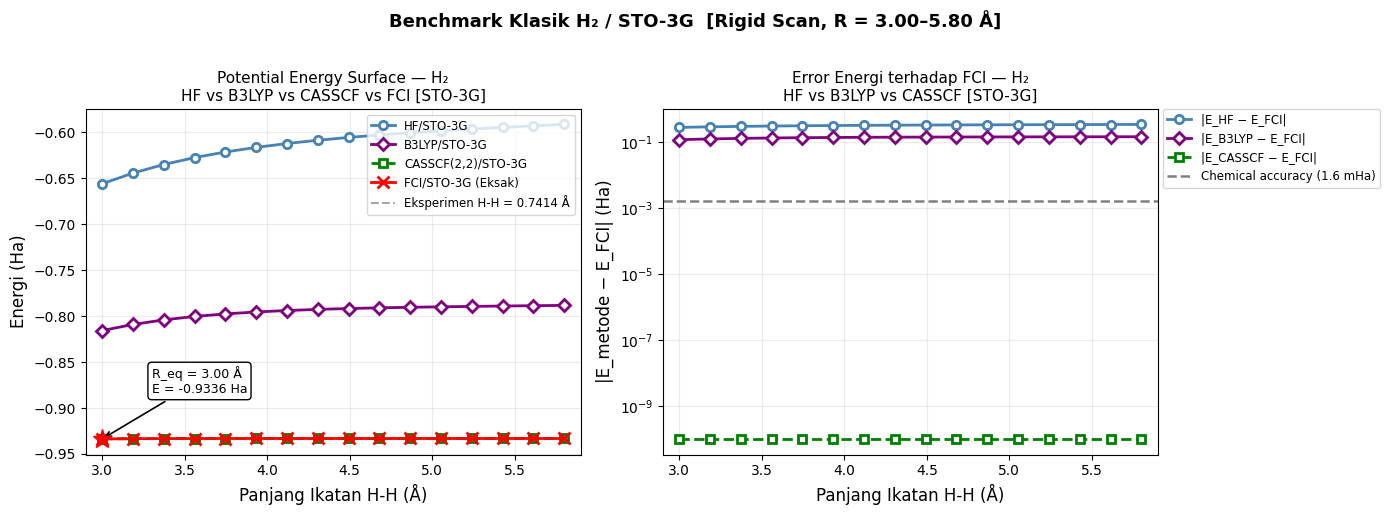

Tersimpan: Benchmark_H2_Rigid_Scan,_R_=_3.00–5.80_Å.png


In [3]:
plot_h2(R2, E_HF_2, E_DFT_2, E_CASSCF_2, E_FCI_2,
        '[Rigid Scan, R = 3.00–5.80 Å]',
        xlim=(2.9, 5.9))

## Plot 3 — Gabungan: R = 0.50–5.80 Å

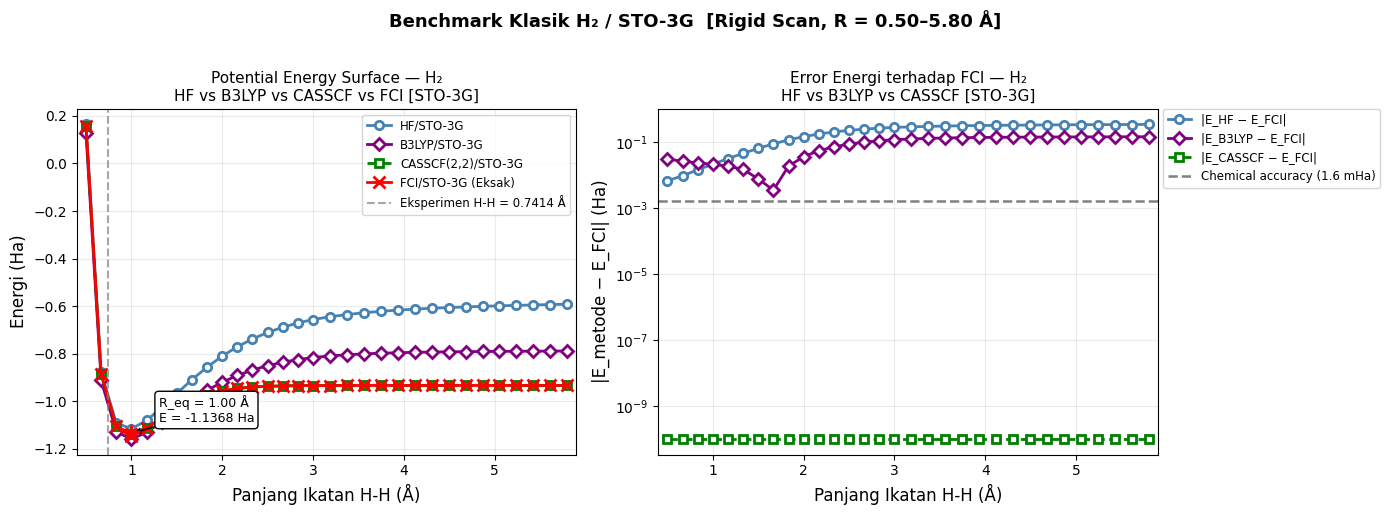

Tersimpan: Benchmark_H2_Rigid_Scan,_R_=_0.50–5.80_Å.png


In [4]:
plot_h2(R_gab, E_HF_gab, E_DFT_gab, E_CASSCF_gab, E_FCI_gab,
        '[Rigid Scan, R = 0.50–5.80 Å]',
        xlim=(0.4, 5.9))